In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import time
import matplotlib.pyplot as plt
import matplotlib as mpl
import argparse
import json

from src.data.place_cells import PlaceCells
from src.data.trajectory_generator import TrajectoryGenerator
from src.model import RNN, MultilayerPCN, TemporalPCN
from src.trainer import Trainer, PCTrainer
from src.visualize import *
import src.utils as utils
# from pypalettes import load_cmap

import pandas as pd
import seaborn as sns

In [2]:
%load_ext autoreload
%autoreload 2

## Static PCN

In [3]:
def normalize(loss):
    return (loss - min(loss)) / (max(loss) - min(loss))

In [39]:
pcn_paths = ['../results/pcn/Mar-22-2025-14-55-44', '../results/pcn/Mar-23-2025-11-59-41', '../results/pcn/Mar-23-2025-12-06-05']
tpc_long_paths = ['../results/tpc/Mar-22-2025-15-04-41', '../results/tpc/Mar-22-2025-16-19-03', '../results/tpc/Mar-22-2025-16-25-17']
tpc_short_paths = ['../results/tpc/Mar-22-2025-15-28-57', '../results/tpc/Mar-22-2025-16-41-36', '../results/tpc/Mar-22-2025-17-13-05']

In [40]:
def collect_metrics(pcn_path, tpc_long_path, tpc_short_path, n_cells=64, n_epochs=30):
    pcn_avg_scores = []
    tpc_long_avg_scores = []
    tpc_short_avg_scores = []
    pcn_avg_proportions = []
    tpc_long_avg_proportions = []
    tpc_short_avg_proportions = []

    for i in tqdm(range(n_epochs)):
        pcn_metrics = np.load(os.path.join(pcn_path, f"epoch{i}/gc_sac_scores.npz"))
        pcn_scores = pcn_metrics['scores'][:n_cells]
        tpc_long_scores = np.load(os.path.join(tpc_long_path, f"grid_scores/grid_scores_epoch_{i}.npy"))
        tpc_long_scores = tpc_long_scores[:n_cells]
        tpc_short_scores = np.load(os.path.join(tpc_short_path, f"grid_scores/grid_scores_epoch_{i}.npy"))
        tpc_short_scores = tpc_short_scores[:n_cells]
        pcn_avg_scores.append(pcn_scores.mean())
        tpc_long_avg_scores.append(tpc_long_scores.mean())
        tpc_short_avg_scores.append(tpc_short_scores.mean())

        pcn_sac = pcn_metrics['sacs'][:n_cells]
        tpc_long_sac = np.load(os.path.join(tpc_long_path, f"sacs/sacs_epoch_{i}.npy"))
        tpc_long_sac = tpc_long_sac[:n_cells]
        tpc_short_sac = np.load(os.path.join(tpc_short_path, f"sacs/sacs_epoch_{i}.npy"))
        tpc_short_sac = tpc_short_sac[:n_cells]

        pcn_proportions = []
        tpc_long_proportions = []
        tpc_short_proportions = []
        for c in range(n_cells):
            pcn_metrics = compute_grid_metrics(pcn_sac[c])
            tpc_long_metrics = compute_grid_metrics(tpc_long_sac[c])
            tpc_short_metrics = compute_grid_metrics(tpc_short_sac[c])
            pcn_proportions.append(pcn_metrics['grid_size_meters'] / pcn_metrics['grid_scale_meters'])
            tpc_long_proportions.append(tpc_long_metrics['grid_size_meters'] / tpc_long_metrics['grid_scale_meters'])
            tpc_short_proportions.append(tpc_short_metrics['grid_size_meters'] / tpc_short_metrics['grid_scale_meters'])
        pcn_avg_proportions.append(np.mean(pcn_proportions))
        tpc_long_avg_proportions.append(np.mean(tpc_long_proportions))
        tpc_short_avg_proportions.append(np.mean(tpc_short_proportions))

    pcn_loss = np.load(os.path.join(pcn_path, 'training_loss.npy'))[:n_epochs]
    tpc_long_loss = np.load(os.path.join(tpc_long_path, 'loss.npy'))[:n_epochs]
    tpc_short_loss = np.load(os.path.join(tpc_short_path, 'loss.npy'))[:n_epochs]

    metrics = {
        'pcn_avg_scores': pcn_avg_scores,
        'pcn_avg_proportions': pcn_avg_proportions,
        'tpc_long_avg_scores': tpc_long_avg_scores,
        'tpc_long_avg_proportions': tpc_long_avg_proportions,
        'tpc_short_avg_scores': tpc_short_avg_scores,
        'tpc_short_avg_proportions': tpc_short_avg_proportions,
        'pcn_loss': pcn_loss,
        'tpc_long_loss': tpc_long_loss,
        'tpc_short_loss': tpc_short_loss
    }
    return metrics


In [45]:
n_epochs = 30
n_cells = 64
pcn_losses = np.zeros((n_epochs, 3))
tpc_long_losses = np.zeros((n_epochs, 3))
tpc_short_losses = np.zeros((n_epochs, 3))
pcn_scores = np.zeros((n_epochs, 3))
tpc_long_scores = np.zeros((n_epochs, 3))
tpc_short_scores = np.zeros((n_epochs, 3))
pcn_proportions = np.zeros((n_epochs, 3))
tpc_long_proportions = np.zeros((n_epochs, 3))
tpc_short_proportions = np.zeros((n_epochs, 3))
for i in range(3):
    pcn_path = pcn_paths[i]
    tpc_long_path = tpc_long_paths[i]
    tpc_short_path = tpc_short_paths[i]
    metrics = collect_metrics(pcn_path, tpc_long_path, tpc_short_path, n_cells=n_cells, n_epochs=n_epochs)
    pcn_losses[:, i] = normalize(metrics['pcn_loss'])
    tpc_long_losses[:, i] = normalize(metrics['tpc_long_loss'])
    tpc_short_losses[:, i] = normalize(metrics['tpc_short_loss'])
    pcn_scores[:, i] = normalize(metrics['pcn_avg_scores'])
    tpc_long_scores[:, i] = normalize(metrics['tpc_long_avg_scores'])
    tpc_short_scores[:, i] = normalize(metrics['tpc_short_avg_scores'])
    pcn_proportions[:, i] = normalize(metrics['pcn_avg_proportions'])   
    tpc_long_proportions[:, i] = normalize(metrics['tpc_long_avg_proportions'])
    tpc_short_proportions[:, i] = normalize(metrics['tpc_short_avg_proportions'])

# for each of loss, score and proportion, collect the mean and std across the 3 runs in arrays
losses = [pcn_losses, tpc_long_losses, tpc_short_losses]
scores = [pcn_scores, tpc_long_scores, tpc_short_scores]
proportions = [pcn_proportions, tpc_long_proportions, tpc_short_proportions]
mean_losses = [np.mean(loss, axis=1) for loss in losses]
std_losses = [np.std(loss, axis=1)/3 for loss in losses]
mean_scores = [np.mean(score, axis=1) for score in scores]
std_scores = [np.std(score, axis=1)/3 for score in scores]
mean_proportions = [np.mean(proportion, axis=1) for proportion in proportions]
std_proportions = [np.std(proportion, axis=1)/3 for proportion in proportions]


100%|██████████| 30/30 [00:14<00:00,  2.08it/s]


Text(0.5, 0, 'Epoch')

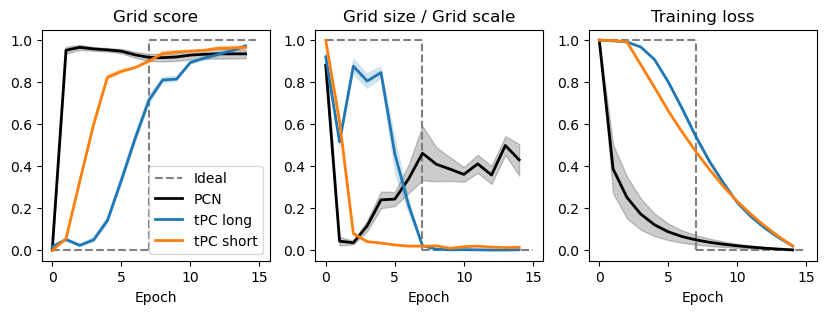

In [60]:
k = 2

fig, ax = plt.subplots(1, 3, figsize=(10, 3))
ax[0].hlines(0, 0, 7, color='gray', ls='--')
ax[0].plot([7, 7], [0, 1], color='gray', ls='--', label='Ideal')
ax[0].hlines(1, 7, 15, color='gray', ls='--')
ax[0].plot(mean_scores[0][::k], label='PCN', color='k', lw=2)
ax[0].fill_between(np.arange(0, n_epochs//k), 
                   (mean_scores[0] - std_scores[0])[::k], 
                   (mean_scores[0] + std_scores[0])[::k], 
                   color='k', alpha=0.2)
ax[0].plot(mean_scores[1][::k], label='tPC long', lw=2)
ax[0].fill_between(np.arange(0, n_epochs//k), 
                   (mean_scores[1] - std_scores[1])[::k], 
                   (mean_scores[1] + std_scores[1])[::k], 
                   alpha=0.2)
ax[0].plot(mean_scores[2][::k], label='tPC short', lw=2)
ax[0].fill_between(np.arange(0, n_epochs//k), 
                   (mean_scores[2] - std_scores[2])[::k], 
                   (mean_scores[2] + std_scores[2])[::k], 
                   alpha=0.2)
ax[0].set_title('Grid score')
ax[0].set_xlabel('Epoch')
ax[0].legend()

ax[1].hlines(1, 0, 7, color='gray', ls='--')
ax[1].plot([7, 7], [0, 1], color='gray', ls='--')
ax[1].hlines(0, 7, 15, color='gray', ls='--')
ax[1].plot(mean_proportions[0][::k], label='PCN', color='k', lw=2)
ax[1].fill_between(np.arange(0, n_epochs//k), 
                   (mean_proportions[0] - std_proportions[0])[::k], 
                   (mean_proportions[0] + std_proportions[0])[::k], 
                   color='k', alpha=0.2)
ax[1].plot(mean_proportions[1][::k], label='tPC long', lw=2)
ax[1].fill_between(np.arange(0, n_epochs//k), 
                   (mean_proportions[1] - std_proportions[1])[::k], 
                   (mean_proportions[1] + std_proportions[1])[::k], 
                   alpha=0.2)
ax[1].plot(mean_proportions[2][::k], label='tPC short', lw=2)
ax[1].fill_between(np.arange(0, n_epochs//k), 
                   (mean_proportions[2] - std_proportions[2])[::k], 
                   (mean_proportions[2] + std_proportions[2])[::k], 
                   alpha=0.2)
ax[1].set_title('Grid size / Grid scale')
ax[1].set_xlabel('Epoch')

ax[2].hlines(1, 0, 7, color='gray', ls='--')
ax[2].plot([7, 7], [0, 1], color='gray', ls='--')
ax[2].hlines(0, 7, 15, color='gray', ls='--')
ax[2].plot(mean_losses[0][::k], label='PCN', color='k', lw=2)
ax[2].fill_between(np.arange(0, n_epochs//k), 
                   (mean_losses[0] - std_losses[0])[::k], 
                   (mean_losses[0] + std_losses[0])[::k], 
                   color='k', alpha=0.2)
ax[2].plot(mean_losses[1][::k], label='tPC long', lw=2)
ax[2].fill_between(np.arange(0, n_epochs//k), 
                   (mean_losses[1] - std_losses[1])[::k], 
                   (mean_losses[1] + std_losses[1])[::k], 
                   alpha=0.2)
ax[2].plot(mean_losses[2][::k], label='tPC short', lw=2)
ax[2].fill_between(np.arange(0, n_epochs//k), 
                   (mean_losses[2] - std_losses[2])[::k], 
                   (mean_losses[2] + std_losses[2])[::k], 
                   alpha=0.2)
ax[2].set_title('Training loss')
ax[2].set_xlabel('Epoch')


## SAC and field size

In [65]:
def get_grid_metrics(path, n_cells, env_size, size_threshold=0.2):
    sacs = np.load(f"../results/tpc/{path}/sac.npy")[:n_cells]
    scores = np.load(f"../results/tpc/{path}/grid_scores.npy")
    sizes = []
    scales = []
    for i in range(sacs.shape[0]):
        sac = sacs[i]
        res = compute_grid_metrics(sac, env_size=env_size, size_thresh_scaler=size_threshold, scale_method='average')
        grid_scale = res['grid_scale_meters']
        grid_size = res['grid_size_meters']
        sizes.append(grid_size)
        scales.append(grid_scale)
    return sizes, scales, scores

### field size and scale as a function of speed and arena size

In [101]:
speeds = [0.02, 0.05, 0.1]
models_speeds = ["Mar-24-2025-10-48-57", "Mar-24-2025-12-43-10", "Mar-24-2025-14-38-05"]
n_cells = 32
env_size = 1.6
size_threshold = 0.25
sizes_mean, scales_mean = [], []
sizes_std, scales_std = [], []
scores_all = []
for i, speed in enumerate(speeds):
    sizes, scales, scores = get_grid_metrics(models_speeds[i], n_cells, env_size, size_threshold)
    sizes_mean.append(np.mean(sizes))
    sizes_std.append(np.std(sizes))
    scales_mean.append(np.mean(scales))
    scales_std.append(np.std(scales))
    scores_all.append(scores)

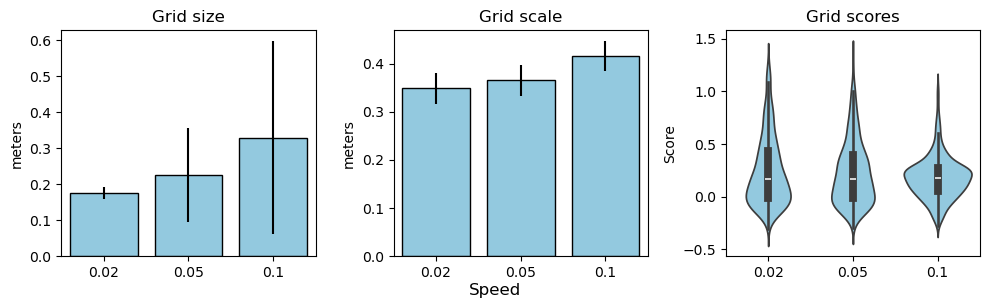

In [103]:
x = [str(speed) for speed in speeds]
fig, ax = plt.subplots(1, 3, figsize=(10, 3))
sns.barplot(x=x, y=sizes_mean, yerr=sizes_std, capsize=5, ax=ax[0], color='skyblue', edgecolor='black')
ax[0].set_title('Grid size')
ax[0].set_ylabel('meters')
sns.barplot(x=x, y=scales_mean, yerr=scales_std, capsize=5, ax=ax[1], color='skyblue', edgecolor='black')
ax[1].set_title('Grid scale')
ax[1].set_ylabel('meters')
#violin plot of scores
sns.violinplot(data=scores_all, ax=ax[2], color='skyblue')
ax[2].set_title('Grid scores')
ax[2].set_ylabel('Score')
ax[2].set_xticks([0,1,2], x)
# add a x-axis label across all subplots
fig.text(0.5, 0., 'Speed', ha='center', fontsize=12)
plt.tight_layout()


In [91]:
env_sizes = [1.2, 1.6, 2.0]
models_arena = ["Mar-24-2025-10-53-54", "Mar-24-2025-10-48-57", "Mar-24-2025-12-38-00"]
n_cells = 64
size_threshold = 0.25
sizes_mean, scales_mean = [], []
sizes_std, scales_std = [], []
scores_all = []
for env_size, path in zip(env_sizes, models_arena):
    sizes, scales, scores = get_grid_metrics(path, n_cells, env_size, size_threshold)

    sizes_mean.append(np.mean(sizes))
    scales_mean.append(np.mean(scales))
    
    sizes_std.append(np.std(sizes))
    scales_std.append(np.std(scales))
    
    scores_all.append(scores)

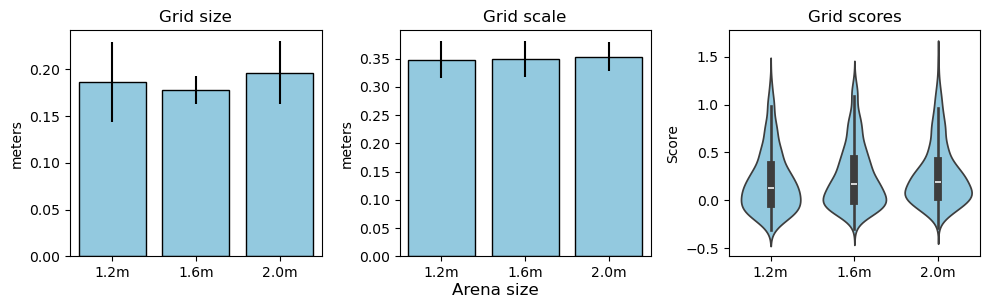

In [92]:
fig, ax = plt.subplots(1, 3, figsize=(10, 3))
sns.barplot(x=['1.2m', '1.6m', '2.0m'], y=sizes_mean, yerr=sizes_std, capsize=5, ax=ax[0], color='skyblue', edgecolor='black')
ax[0].set_title('Grid size')
ax[0].set_ylabel('meters')
sns.barplot(x=['1.2m', '1.6m', '2.0m'], y=scales_mean, yerr=scales_std, capsize=5, ax=ax[1], color='skyblue', edgecolor='black')
ax[1].set_title('Grid scale')
ax[1].set_ylabel('meters')
#violin plot of scores
sns.violinplot(data=scores_all, ax=ax[2], color='skyblue')
ax[2].set_title('Grid scores')
ax[2].set_ylabel('Score')
ax[2].set_xticks([0,1,2], ['1.2m', '1.6m', '2.0m'])
# add a x-axis label across all subplots
fig.text(0.5, 0., 'Arena size', ha='center', fontsize=12)
plt.tight_layout()


<Axes: ylabel='Density'>

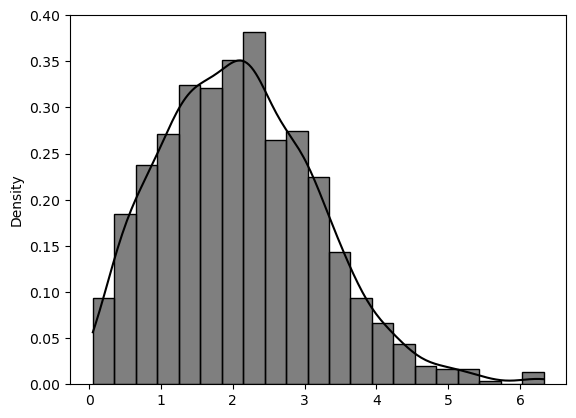

In [33]:
x = np.random.rayleigh(0.13 * 4 * np.pi, 1000)
sns.histplot(x, kde=True, stat='density', color='k')

0.13984375000000004 0.05874979222037726


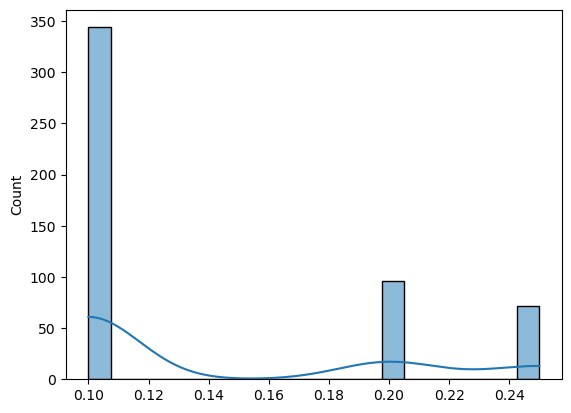

In [29]:
pc_sizes = np.random.choice([0.1, 0.2, 0.25], size=512, p=[0.65, 0.2, 0.15])
# add noise to the sizes, based on their value
# pc_sizes += np.random.normal(0, 0.01/pc_sizes, size=512)
sns.histplot(pc_sizes, bins=20, kde=True)
print(pc_sizes.mean(), pc_sizes.std())

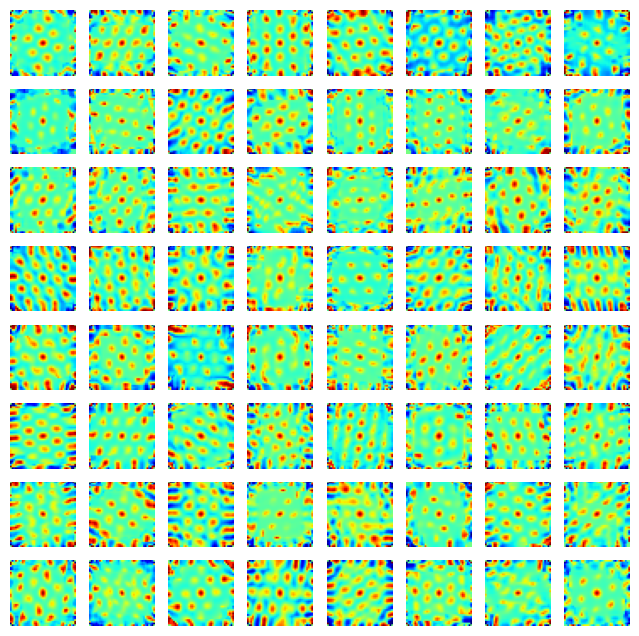

In [104]:
model_path = "Mar-24-2025-10-48-57"
sac = np.load(f"../results/tpc/{model_path}/sac.npy")
fig, ax = plt.subplots(8, 8, figsize=(8, 8))
for i in range(8):
    for j in range(8):
        ax[i, j].imshow(sac[i*8+j], cmap='jet')
        ax[i, j].axis('off')

4.47213595499958 8.602325267042627


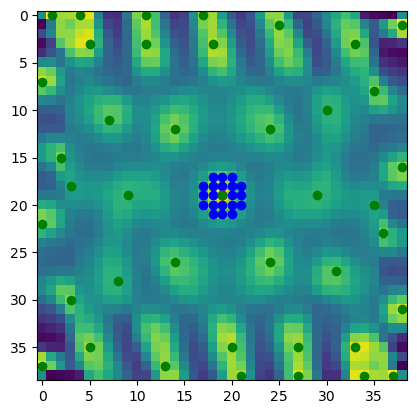

In [105]:
sac0 = sac[31]
global_maximum = find_global_maxima(sac0)
local_maxima = find_local_maxima(sac0)
central_field_coords = find_central_field_pixels(sac0, *global_maximum)
size_px, size_m = compute_diameter(central_field_coords, 0.1)
scale_px, scale_m = get_grid_scale(local_maxima, global_maximum, 0.1)
print(size_px, scale_px)
plt.imshow(sac0)
plt.scatter(central_field_coords[:, 1], central_field_coords[:, 0], color='blue')
plt.scatter(global_maximum[1], global_maximum[0], color='red')
for peak in local_maxima:
    plt.scatter(peak[1], peak[0], color='green')


In [110]:
sample_size = 32
size_threshold = 0.25
fixed_sizes, fixed_scales, fixed_scores = get_grid_metrics("Mar-24-2025-10-48-57", sample_size, 1.6, size_threshold)
random_sizes, random_scales, random_scores = get_grid_metrics("Mar-24-2025-11-01-33", sample_size, 1.6, size_threshold)

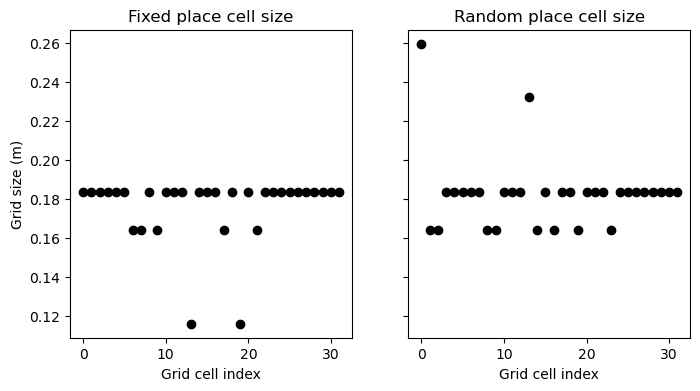

In [111]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
ax[0].scatter(np.arange(sample_size), fixed_sizes, color='k')
ax[0].set_title("Fixed place cell size")
ax[0].set_ylabel("Grid size (m)")
ax[0].set_xlabel("Grid cell index")
ax[1].scatter(np.arange(sample_size), random_sizes, color='k')
ax[1].set_title("Random place cell size")
ax[1].set_xlabel("Grid cell index")
plt.show()

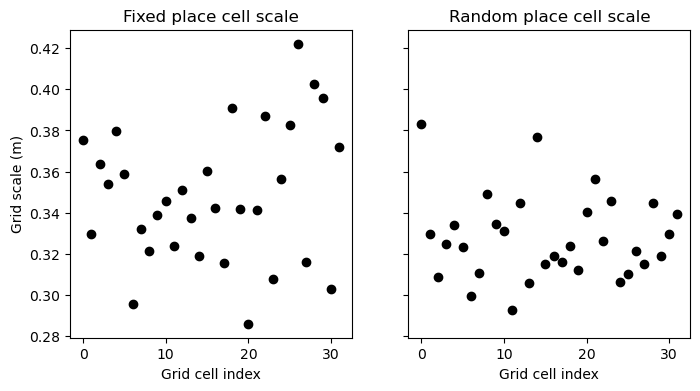

In [112]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
ax[0].scatter(np.arange(sample_size), fixed_scales, color='k')
ax[0].set_title("Fixed place cell scale")
ax[0].set_ylabel("Grid scale (m)")
ax[0].set_xlabel("Grid cell index")
ax[1].scatter(np.arange(sample_size), random_scales, color='k')
ax[1].set_title("Random place cell scale")
ax[1].set_xlabel("Grid cell index")
plt.show()


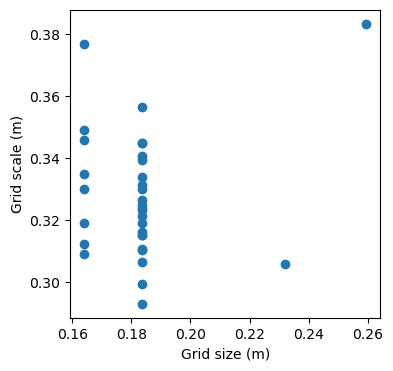

In [113]:
plt.figure(figsize=(4, 4))
plt.scatter(random_sizes, random_scales)
plt.xlabel("Grid size (m)")
plt.ylabel("Grid scale (m)")
plt.show()

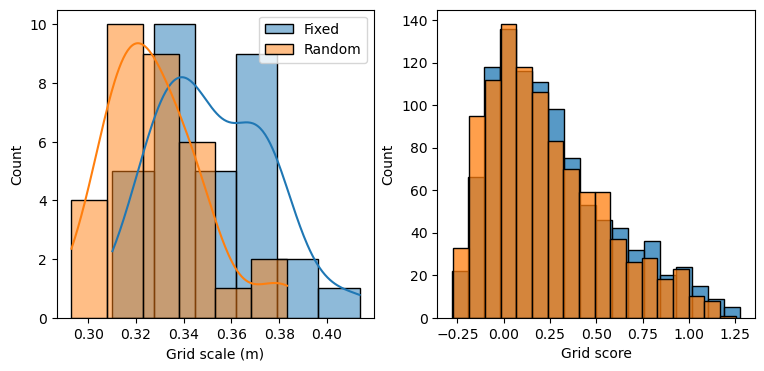

In [58]:
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
sns.histplot(fixed_scales, ax=ax[0], label='Fixed', kde=True)
sns.histplot(random_scales, ax=ax[0], label='Random', kde=True)
ax[0].set_xlabel('Grid scale (m)')
ax[0].legend()

sns.histplot(fixed_scores, ax=ax[1], label='Fixed')
sns.histplot(random_scores, ax=ax[1], label='Random')
ax[1].set_xlabel('Grid score')
plt.show()

## Left vs right 

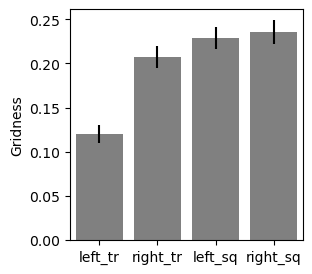

In [4]:
left_scores_tr = np.load('../results/tpc/Jan-31-2025-16-58-27/left_grid_scores.npy')
right_scores_tr = np.load('../results/tpc/Jan-31-2025-16-58-27/right_grid_scores.npy')
left_scores_sq = np.load('../results/tpc/Feb-01-2025-17-55-06/left_grid_scores.npy')
right_scores_sq = np.load('../results/tpc/Feb-01-2025-17-55-06/right_grid_scores.npy')

data = pd.DataFrame({
    'left_tr': right_scores_tr,
    'right_tr': left_scores_tr,
    'left_sq': right_scores_sq,
    'right_sq': left_scores_sq,
})

# Compute mean and standard deviation
means = data.mean()
stds = data.std()
ci_95 = 1.96 * (stds / np.sqrt(data.shape[0]))

# Convert to a new DataFrame for seaborn
stats_df = pd.DataFrame({'Column': means.index, 'Mean': means.values, 'CI_95': ci_95.values})

# Plot using seaborn, making sure they share the same color
plt.figure(figsize=(3, 3))
sns.barplot(x="Column", y="Mean", data=stats_df, yerr=stats_df["CI_95"], capsize=0.2, color='grey')

# Labels and title
plt.ylabel("Gridness")
# plt.title("Mean and Standard Deviation of Each Column")
plt.xlabel("")
plt.show()

## Development of grid scores over learning

In [3]:
def sac_rm_develop(model_path, n_epochs, save_every, n_cells=8):
    sacs = []
    scores = []
    rms = []
    for epoch in range(0, n_epochs+save_every, save_every):
        sac = np.load(f"../results/tpc/{model_path}/sacs/sacs_epoch_{epoch}.npy")[:n_cells]
        score = np.load(f'../results/tpc/{model_path}/grid_scores/grid_scores_epoch_{epoch}.npy')[:n_cells]
        rm = np.load(f'../results/tpc/{model_path}/rate_maps_epoch/rate_map_epoch_{epoch}.npy')[:n_cells]
        sacs.append(sac)
        scores.append(score)
        rms.append(rm)
    return sacs, scores, rms

In [4]:
def gridness_develop(model_path, n_epochs, save_every):
    data = {}
    for epoch in range(0, n_epochs, save_every):
        scores = np.load(f'../results/tpc/{model_path}/grid_scores/grid_scores_epoch_{epoch}.npy')
        data[epoch] = scores[:128]
    data = pd.DataFrame(data)
    means = data.mean()
    stds = data.std()
    sem = stds / np.sqrt(data.shape[0])

    stats_df = pd.DataFrame({'Epoch': means.index, 'Mean': means.values, 'Sem': sem.values})

    return stats_df
    

In [36]:
def scale_size_develop(model_path, n_epochs, save_every, n_cells):
    data_proportion = {}
    data_size = {}
    data_scale = {}
    for epoch in range(0, n_epochs, save_every):
        sac = np.load(f'../results/tpc/{model_path}/sacs/sacs_epoch_{epoch}.npy')
        sac = sac[:n_cells]
        proportions = []
        sizes = []
        scales = []
        for i in range(sac.shape[0]):
            res = compute_grid_metrics(sac[i])
            grid_scale = res['grid_scale_meters']
            grid_size = res['grid_size_meters']
            sizes.append(grid_size)
            scales.append(grid_scale)
            proportions.append(grid_size / grid_scale)
        data_proportion[epoch] = proportions
        data_size[epoch] = sizes
        data_scale[epoch] = scales

    data_proportion = pd.DataFrame(data_proportion)
    means_proportion = data_proportion.mean()
    stds_proportion = data_proportion.std()
    sem_proportion = stds_proportion / np.sqrt(data_proportion.shape[0])
    stats_df_proportion = pd.DataFrame({'Epoch': means_proportion.index, 'Mean': means_proportion.values, 'Sem': sem_proportion.values})

    data_size = pd.DataFrame(data_size)
    means_size = data_size.mean()
    stds_size = data_size.std()
    sem_size = stds_size / np.sqrt(data_size.shape[0])
    stats_df_size = pd.DataFrame({'Epoch': means_size.index, 'Mean': means_size.values, 'Sem': sem_size.values})

    data_scale = pd.DataFrame(data_scale)
    means_scale = data_scale.mean()
    stds_scale = data_scale.std()
    sem_scale = stds_scale / np.sqrt(data_scale.shape[0])
    stats_df_scale = pd.DataFrame({'Epoch': means_scale.index, 'Mean': means_scale.values, 'Sem': sem_scale.values})


    return stats_df_proportion, stats_df_size, stats_df_scale

In [44]:
short_path = "Mar-05-2025-09-16-28"
long_path = "Mar-05-2025-06-31-37"
xlong_path = "Mar-12-2025-12-28-10"
n_cells = 2
short_sacs, short_scores, short_rms = sac_rm_develop(short_path, 15, 1, n_cells)
long_sacs, long_scores, long_rms = sac_rm_develop(long_path, 15, 1, n_cells)
xlong_sacs, xlong_scores, xlong_rms = sac_rm_develop(xlong_path, 30, 1, n_cells)

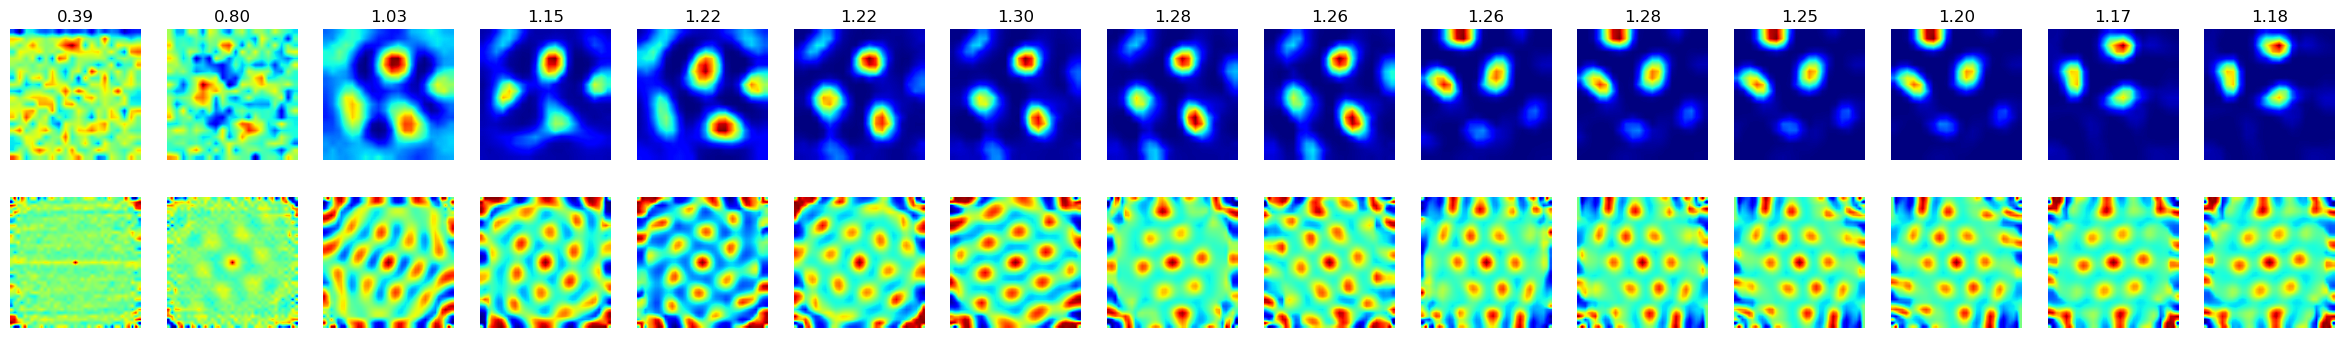

In [41]:
fig, ax = plt.subplots(2, 15, figsize=(30, n_cells * 2))
for j in range(15):
    ax[0, j].imshow(short_rms[j][0], cmap='jet', interpolation='bilinear')
    ax[0, j].axis('off')
    ax[0, j].set_title(f"{short_scores[j][0]:.2f}")

    ax[1, j].imshow(short_sacs[j][1], cmap='jet', interpolation='bilinear')
    ax[1, j].axis('off')

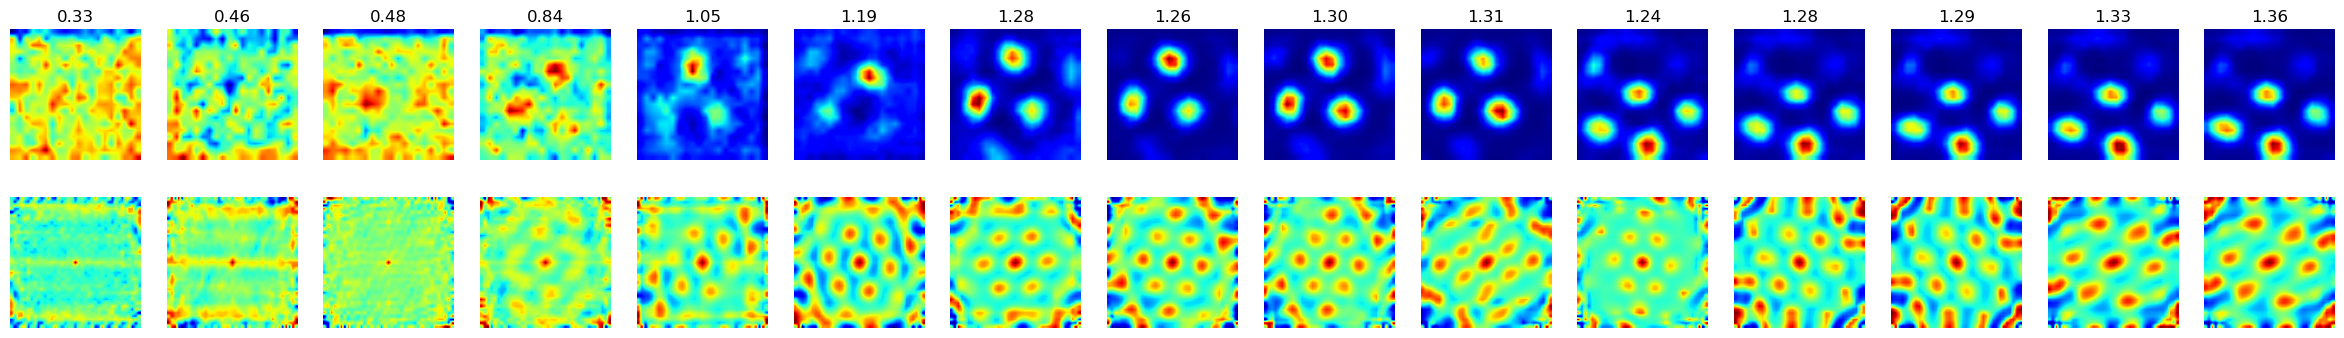

In [42]:
fig, ax = plt.subplots(2, 15, figsize=(30, n_cells * 2))
for j in range(15):
    ax[0, j].imshow(long_rms[j][0], cmap='jet', interpolation='bilinear')
    ax[0, j].axis('off')
    ax[0, j].set_title(f"{long_scores[j][0]:.2f}")

    ax[1, j].imshow(long_sacs[j][1], cmap='jet', interpolation='bilinear')
    ax[1, j].axis('off')

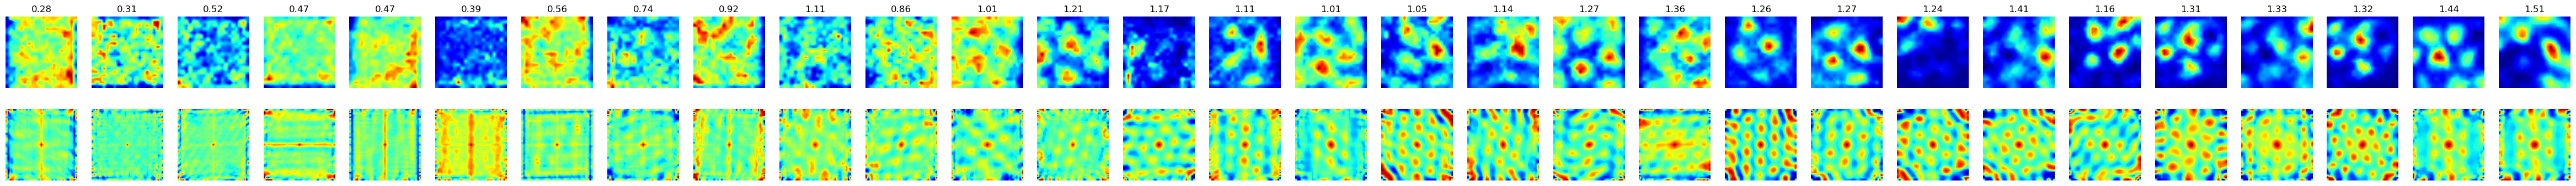

In [46]:
fig, ax = plt.subplots(2, 30, figsize=(60, n_cells * 2))
for j in range(30):
    ax[0, j].imshow(xlong_rms[j][0], cmap='jet', interpolation='bilinear')
    ax[0, j].axis('off')
    ax[0, j].set_title(f"{xlong_scores[j][0]:.2f}")

    ax[1, j].imshow(xlong_sacs[j][1], cmap='jet', interpolation='bilinear')
    ax[1, j].axis('off')

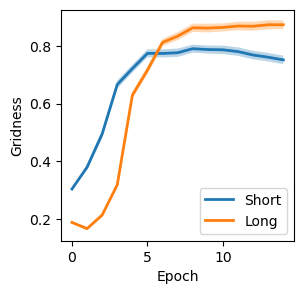

In [52]:
short_stats = gridness_develop(short_path, 15, 1)
long_stats = gridness_develop(long_path, 15, 1)
xlong_stats = gridness_develop(xlong_path, 30, 1)
plt.figure(figsize=(3, 3))
plt.plot(short_stats['Epoch'], short_stats['Mean'], label='Short', lw=2)
plt.fill_between(short_stats['Epoch'], short_stats['Mean'] - short_stats['Sem'], short_stats['Mean'] + short_stats['Sem'], alpha=0.3)
plt.plot(long_stats['Epoch'], long_stats['Mean'], label='Long', lw=2)
plt.fill_between(long_stats['Epoch'], long_stats['Mean'] - long_stats['Sem'], long_stats['Mean'] + long_stats['Sem'], alpha=0.3)
plt.legend()
plt.ylabel("Gridness")
plt.xlabel("Epoch")
plt.show()

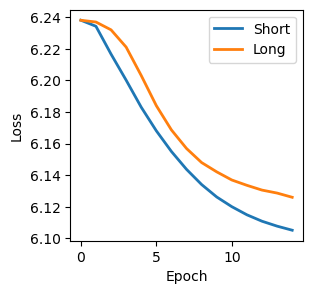

In [48]:
short_loss = np.load(f'../results/tpc/{short_path}/loss.npy')
long_loss = np.load(f'../results/tpc/{long_path}/loss.npy')

plt.figure(figsize=(3, 3))
plt.plot(short_loss, label='Short', lw=2)
plt.plot(long_loss, label='Long', lw=2)
plt.legend()
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

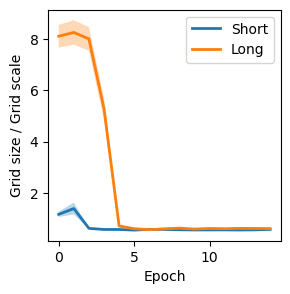

In [53]:
short_proportions, short_sizes, short_scales = scale_size_develop(short_path, 15, 1, 128)
long_proportions, long_sizes, long_scales = scale_size_develop(long_path, 15, 1, 128)
xlong_proportions, xlong_sizes, xlong_scales = scale_size_develop(xlong_path, 30, 1, 128)
plt.figure(figsize=(3, 3))
plt.plot(short_proportions['Epoch'], short_proportions['Mean'], label='Short', lw=2)
plt.fill_between(short_proportions['Epoch'], short_proportions['Mean'] - short_proportions['Sem'], short_proportions['Mean'] + short_proportions['Sem'], alpha=0.3)
plt.plot(long_proportions['Epoch'], long_proportions['Mean'], label='Long', lw=2)
plt.fill_between(long_proportions['Epoch'], long_proportions['Mean'] - long_proportions['Sem'], long_proportions['Mean'] + long_proportions['Sem'], alpha=0.3)
plt.legend()
plt.ylabel("Grid size / Grid scale")
plt.xlabel("Epoch")
plt.show()

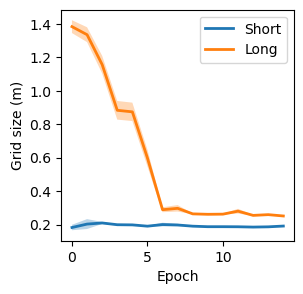

In [38]:
plt.figure(figsize=(3, 3))
plt.plot(short_sizes['Epoch'], short_sizes['Mean'], label='Short', lw=2)
plt.fill_between(short_sizes['Epoch'], short_sizes['Mean'] - short_sizes['Sem'], short_sizes['Mean'] + short_sizes['Sem'], alpha=0.3)
plt.plot(long_sizes['Epoch'], long_sizes['Mean'], label='Long', lw=2)
plt.fill_between(long_sizes['Epoch'], long_sizes['Mean'] - long_sizes['Sem'], long_sizes['Mean'] + long_sizes['Sem'], alpha=0.3)
plt.legend()
plt.ylabel("Grid size (m)")
plt.xlabel("Epoch")
plt.show()

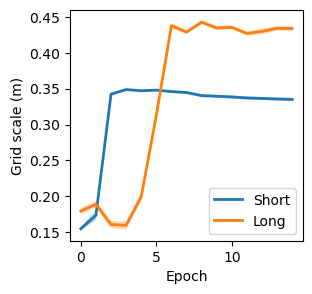

In [39]:
plt.figure(figsize=(3, 3))
plt.plot(short_scales['Epoch'], short_scales['Mean'], label='Short', lw=2)
plt.fill_between(short_scales['Epoch'], short_scales['Mean'] - short_scales['Sem'], short_scales['Mean'] + short_scales['Sem'], alpha=0.3)
plt.plot(long_scales['Epoch'], long_scales['Mean'], label='Long', lw=2)
plt.fill_between(long_scales['Epoch'], long_scales['Mean'] - long_scales['Sem'], long_scales['Mean'] + long_scales['Sem'], alpha=0.3)
plt.legend()
plt.ylabel("Grid scale (m)")
plt.xlabel("Epoch")
plt.show()

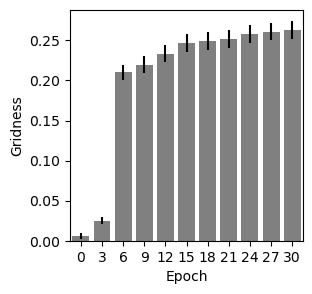

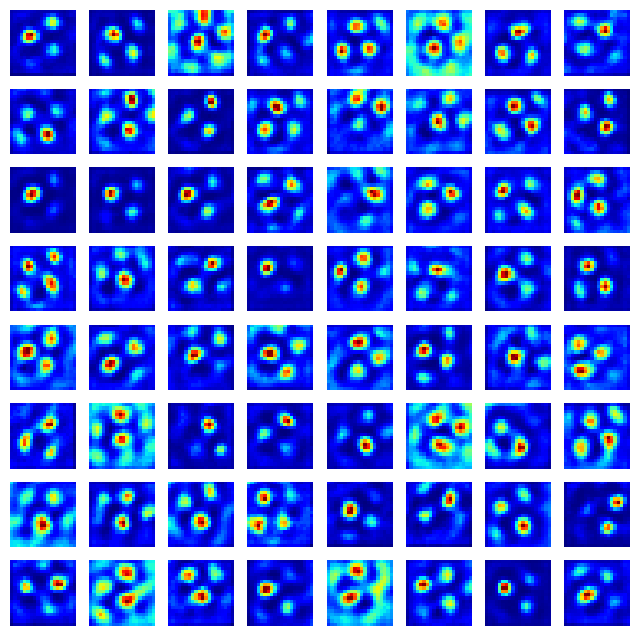

In [15]:
model_path = "Feb-11-2025-03-28-09"
data = {}
for epoch in range(0, 33, 3):
    scores = np.load(f'../results/tpc/{model_path}/grid_scores_epoch_{epoch}.npy')
    data[epoch] = scores
data = pd.DataFrame(data)
means = data.mean()
stds = data.std()
sem = stds / np.sqrt(data.shape[0])

stats_df = pd.DataFrame({'Epoch': means.index, 'Mean': means.values, 'Sem': sem.values})

plt.figure(figsize=(3, 3))
sns.barplot(x="Epoch", y="Mean", data=stats_df, yerr=stats_df["Sem"], capsize=0.2, color='grey')
plt.ylabel("Gridness")
plt.xlabel("Epoch")
plt.show()

rate_map0 = np.load(f'../results/tpc/{model_path}/rate_map_epoch_6.npy')[:64]
fig, ax = plt.subplots(8, 8, figsize=(8, 8))
for i in range(8):
    for j in range(8):
        ax[i, j].imshow(rate_map0[i*8+j], cmap="jet")
        ax[i, j].axis('off')

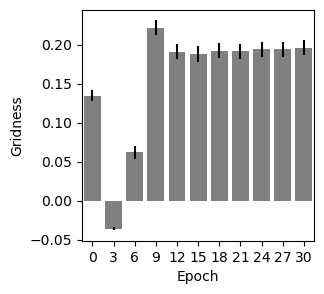

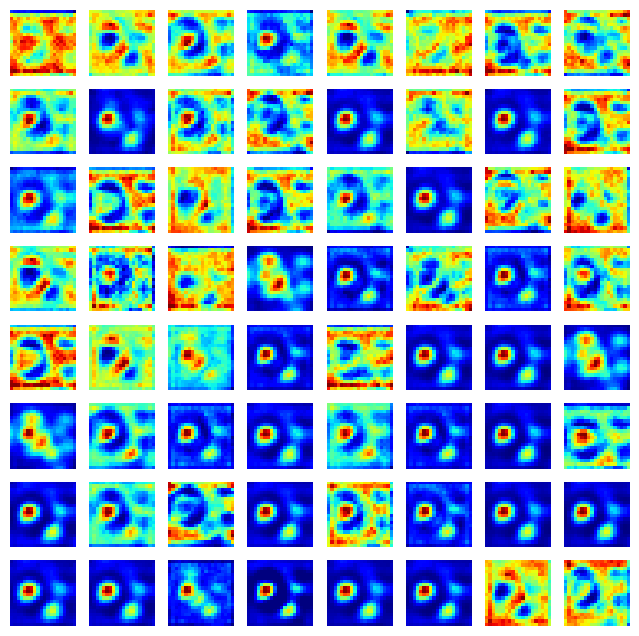

In [11]:
model_path = "Feb-12-2025-15-28-17"
data = {}
for epoch in range(0, 33, 3):
    scores = np.load(f'../results/rnn/{model_path}/grid_scores_epoch_{epoch}.npy')
    data[epoch] = scores
data = pd.DataFrame(data)
means = data.mean()
stds = data.std()
sem = stds / np.sqrt(data.shape[0])

stats_df = pd.DataFrame({'Epoch': means.index, 'Mean': means.values, 'Sem': sem.values})

plt.figure(figsize=(3, 3))
sns.barplot(x="Epoch", y="Mean", data=stats_df, yerr=stats_df["Sem"], capsize=0.2, color='grey')
plt.ylabel("Gridness")
plt.xlabel("Epoch")
plt.show()

rate_map0 = np.load(f'../results/rnn/{model_path}/rate_map_epoch_3.npy')[:64]
fig, ax = plt.subplots(8, 8, figsize=(8, 8))
for i in range(8):
    for j in range(8):
        ax[i, j].imshow(rate_map0[i*8+j], cmap="jet")
        ax[i, j].axis('off')

## Misc

In [2]:
import math
def circle_mask1(size, radius, in_val=1.0, out_val=0.0):
    """Calculating the grid scores with different radius."""
    sz = [math.floor(size[0] / 2), math.floor(size[1] / 2)]
    x = np.linspace(-sz[0], sz[1], size[1])
    x = np.expand_dims(x, 0)
    x = x.repeat(size[0], 0)
    y = np.linspace(-sz[0], sz[1], size[1])
    y = np.expand_dims(y, 1)
    y = y.repeat(size[1], 1)
    z = np.sqrt(x**2 + y**2)
    z = np.less_equal(z, radius)
    vfunc = np.vectorize(lambda b: b and in_val or out_val)
    return vfunc(z)

def circle_mask2(shape, radius):
    """Generates a circular mask with the given radius."""
    y, x = np.ogrid[:shape[0], :shape[1]]
    center_y, center_x = shape[0] // 2, shape[1] // 2
    distance = np.sqrt((x - center_x)**2 + (y - center_y)**2)
    mask = distance <= radius
    return mask.astype(float)

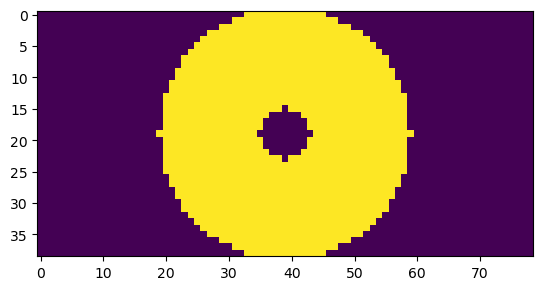

In [3]:
plt.imshow(circle_mask2((39, 79), 20) * (1 - circle_mask2((39, 79), 4)))

In [8]:
sq_scores = np.load('../results/tpc/Jan-23-2025-10-32-41/grid_scores.npy')
tr_scores = np.load('../results/tpc/Jan-23-2025-11-20-40/grid_scores.npy')

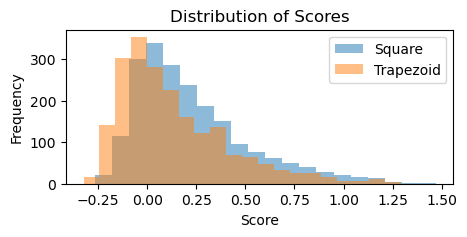

In [9]:
plt.figure(figsize=(5, 2))
plt.hist(sq_scores, bins=20, alpha=0.5, label='Square')
plt.hist(tr_scores, bins=20, alpha=0.5, label='Trapezoid')
plt.legend()
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.title('Distribution of Scores')
plt.show()

In [6]:
tpc_scores = np.load('../results/tpc/Jan-23-2025-18-07-53/grid_scores.npy')
rnn_scores = np.load('../results/rnn/Jan-23-2025-10-58-46/grid_scores.npy')

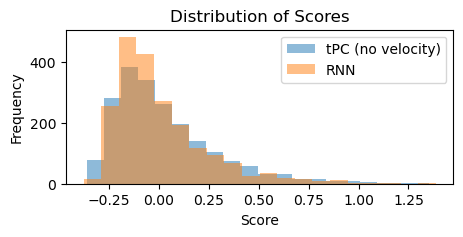

In [8]:
# violin plots of scores
plt.figure(figsize=(5, 2))
plt.hist(tpc_scores, bins=20, alpha=0.5, label='tPC (no velocity)')
plt.hist(rnn_scores, bins=20, alpha=0.5, label='RNN')
plt.legend()
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.title('Distribution of Scores')
plt.show()

In [11]:
np.mean(tpc_scores), np.mean(rnn_scores)

(0.12594252450112184, 0.0033520618915886535)

## Basics

In [4]:
class Options:
    def __init__(self):
        self.device = 'cuda'
        self.oned = False
        self.Np = 512
        self.Ng = 2048
        self.Nv = 2
        self.DoG = True
        self.box_width = 1.4
        self.box_height = 1.4
        self.place_cell_rf = 0.12
        self.surround_scale = 2
        self.periodic = False
        self.sequence_length = 10
        self.dt = 0.02
        self.batch_size = 500
        self.n_epochs = 120
        self.n_steps = 100
        self.learning_rate = 1e-4
        self.weight_decay = 1e-4
        self.decay_step_size = 50
        self.decay_rate = 0.9
        self.lambda_z = 0
        self.lambda_z_init = 0
        self.inf_iters = 20
        self.test_inf_iters = 20
        self.inf_lr = 2e-2
        self.out_activation = 'softmax'
        self.rec_activation = 'relu'
        self.restore = None
        self.preloaded_data = False
        self.save = True
        self.save_every = 50
        self.loss = 'CE'
        self.normalize_pc = 'softmax'
        self.is_wandb = False
        self.sweep = False
        self.mode = 'train'
        self.no_velocity = False
        self.truncating = 1

    def load_from_json(self, json_file):
        with open(json_file, 'r') as file:
            data = json.load(file)
        
        # Set attributes from JSON, skip `_get_args` and `_get_kwargs`
        for key, value in data.items():
            if hasattr(self, key):
                setattr(self, key, value)

    def print_values(self):
        for key, value in self.__dict__.items():
            print(f'{key}: {value}')

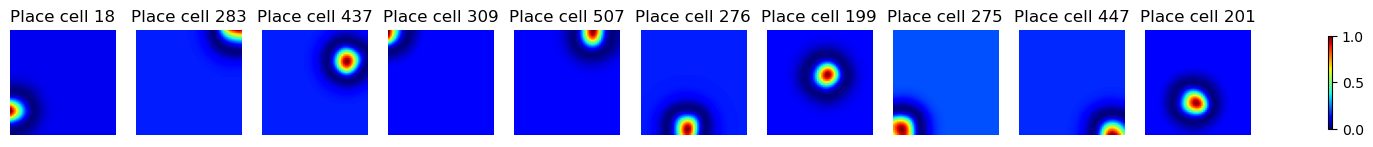

In [5]:
def plot_place_cells(place_cell, options, res, n_show=5):
    grid = np.array(
        np.meshgrid(
            np.linspace(-options.box_width/2, options.box_width/2, res),
            np.linspace(-options.box_height/2, options.box_height/2, res)
        )
    ).T
    grid = torch.tensor(grid, device=options.device)
    grid_pc = place_cell.get_activation(grid)
    select = np.random.choice(np.arange(options.Np), n_show, replace=False)
    fig, axes = plt.subplots(1, n_show, figsize=(n_show*2, 2))
    for i in range(n_show):
        # notice the interpolation arg, which visually makes these 'real' place fields
        pc = grid_pc[:,:,select[i]].cpu().numpy()
        # normalize to [0, 1]
        pc = (pc - pc.min()) / (pc.max() - pc.min())
        im = axes[i].imshow(pc, cmap='jet')
        axes[i].set_title('Place cell {}'.format(select[i]))
        axes[i].axis('off')
    fig.colorbar(im, ax=axes.ravel().tolist(), orientation='vertical', shrink=0.6)
    plt.show()

options = Options()
place_cell = PlaceCells(options)
plot_place_cells(place_cell, options, 55, n_show=10)

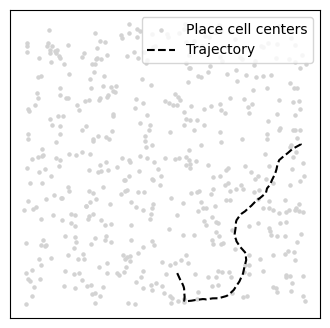

In [6]:
options.sequence_length = 70
trajectory_generator = TrajectoryGenerator(options, place_cell)
inputs, _, pos = trajectory_generator.get_test_batch()
centers = place_cell.centers.cpu()
pos = pos.cpu()
plt.figure(figsize=(4,4))
plt.scatter(centers[:,0], centers[:,1], c='lightgrey', label='Place cell centers', s=5)
for i in range(1):
    plt.plot(pos[i,:,0],pos[i,:,1], label='Trajectory', c='k', ls='--')
    if i==0:
        plt.legend()
plt.xticks([])
plt.yticks([])
# plt.savefig('figures/trjectory.pdf', bbox_inches='tight')
plt.show()

In [7]:
def get_trajetories(tpc_path, rnn_path):
    options_tpc = Options()
    options_rnn = Options()
    tpc_path = os.path.join('../results', 'tpc', tpc_path)
    options_tpc.load_from_json(os.path.join(tpc_path, 'configs.json'))
    ckpt_tpc = torch.load(os.path.join(tpc_path, 'models', 'most_recent_model.pth'), map_location=torch.device(options.device))
    options_tpc.save_dir = tpc_path

    rnn_path = os.path.join('../results', 'rnn', rnn_path)
    options_rnn.load_from_json(os.path.join(rnn_path, 'configs.json'))
    ckpt_rnn = torch.load(os.path.join(rnn_path, 'models', 'most_recent_model.pth'), map_location=torch.device(options.device))
    options_rnn.save_dir = rnn_path

    place_cell = PlaceCells(options_tpc)
    generator = TrajectoryGenerator(options_tpc, place_cell)

    tpc = TemporalPCN(options_tpc).to(options_tpc.device)
    init_model = HierarchicalPCN(options_tpc).to(options_tpc.device)
    tpc.load_state_dict(ckpt_tpc['model'])
    init_model.load_state_dict(ckpt_tpc['init_model'])
    pc_trainer = PCTrainer(options_tpc, tpc, init_model, generator, place_cell, restore=False)

    rnn = RNN(options_rnn, place_cell).to(options_rnn.device)
    rnn.load_state_dict(ckpt_rnn)
    rnn_trainer = Trainer(options_rnn, rnn, generator, place_cell, restore=False)

    # Generate trajectories (one batch)
    inputs, _, pos_batch = generator.get_test_batch()
    pred_rnn, _ = rnn_trainer.predict(inputs)
    pred_rnn = place_cell.get_nearest_cell_pos(F.softmax(pred_rnn.detach(), dim=-1)).detach().cpu().numpy()
    pred_tpc, _ = pc_trainer.predict(inputs)
    pred_tpc = place_cell.get_nearest_cell_pos(F.softmax(pred_tpc.detach(), dim=-1)).detach().cpu().numpy()

    return pos_batch.detach().cpu().numpy(), pred_rnn, pred_tpc

In [20]:
def get_PI_performance(model_path, model='tpc', repeats=5, verbose=False):
    save_dir = os.path.join('../results/', model_path)

    # load the configuration file to args
    options = Options()
    options.load_from_json(os.path.join(save_dir, 'configs.json'))
    if verbose:
        options.print_values()

    # load the model
    ckpt = torch.load(os.path.join(save_dir, 'models', 'most_recent_model.pth'), map_location=torch.device(options.device))
    options.save_dir = save_dir
    place_cell = PlaceCells(options)
    generator = TrajectoryGenerator(options, place_cell)
    if model == 'tpc':
        model = TemporalPCN(options).to(options.device)
        init_model = HierarchicalPCN(options).to(options.device)
        model.load_state_dict(ckpt['model'])
        init_model.load_state_dict(ckpt['init_model'])
        trainer = PCTrainer(options, model, init_model, generator, place_cell, restore=False)
    else:
        model = RNN(options, place_cell).to(options.device)
        model.load_state_dict(ckpt)
        trainer = Trainer(options, model, generator, place_cell, restore=False)
        
    print('Get performance...')
    
    
    errs = []
    baseline_errs = []
    for r in tqdm(range(repeats)):
        inputs, _, pos_batch = generator.get_test_batch()
        pred_xs, _ = trainer.predict(inputs)

        # this softmax intends to find the highest activities among neurons,
        # whcih is different from a nonlinearity
        pred_xs = F.softmax(pred_xs, dim=-1)

        pred_pos = place_cell.get_nearest_cell_pos(pred_xs)
        err = torch.sqrt(((pos_batch.to(options.device) - pred_pos)**2).sum(-1)).mean().item()
        errs.append(err)

        init_pos = pos_batch[:, 0:1, :].repeat(1, options.sequence_length, 1)
        baseline_err = torch.sqrt(((pos_batch - init_pos)**2).sum(-1)).mean().item()
        baseline_errs.append(baseline_err)
    
    return errs, baseline_errs

## Compare sparse (predictive) coding and non-negative PCA

In [7]:
gc_and_scores_pca = np.load('results/pattern_formation/multiple/sorted_gcs.npz')
gc_pca = gc_and_scores_pca['gcs']
scores_pca = gc_and_scores_pca['scores']

gc_and_scores_pcn = np.load('results/pcn/gc_and_scores.npz')
gc_pcn = gc_and_scores_pcn['gcs']
scores_pcn = gc_and_scores_pcn['scores']

In [8]:
gc_pcn.shape

(256, 55, 55)

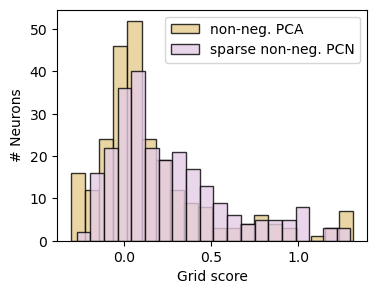

In [16]:
plt.figure(figsize=(4,3))
plt.hist(scores_pca, bins=20, alpha=0.8, label='non-neg. PCA', color='#E5CC8F', edgecolor='black')
plt.hist(scores_pcn, bins=20, alpha=0.8, label='sparse non-neg. PCN', color='#E5CCE5', edgecolor='black')
# # fit a kde to the histogram
# sns.kdeplot(scores_pca, color='#E5CC8F', linestyle='--')
# sns.kdeplot(scores_pcn, color='#E5CCE5', linestyle='--')
plt.xlabel('Grid score')
plt.ylabel('# Neurons')
plt.legend()
plt.savefig('figures/grid_score_hist.pdf', bbox_inches='tight')
plt.show()

In [25]:
def plot_gcs(rate_map, scores, save_name=None, nrow=3, ncol=4):
    fig, ax = plt.subplots(nrow, ncol, figsize=(ncol, nrow))
    for i, ax in enumerate(ax.flatten()):
        r = (rate_map[i] - rate_map[i].min()) / (rate_map[i].max() - rate_map[i].min())
        ax.imshow(r, cmap='jet')
        ax.axis('off')
        ax.set_title(f'{scores[i]:.2f}', fontsize=10)
    plt.tight_layout()
    fig.subplots_adjust(hspace=0.5, right=0.8)
    plt.savefig(f'figures/{save_name}.pdf', bbox_inches='tight')
    plt.show()

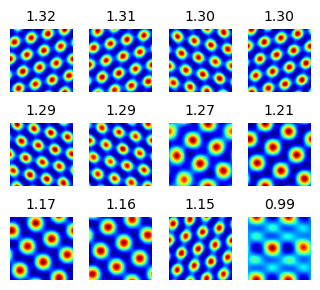

In [15]:
plot_gcs(gc_pca, scores_pca, 'pca_gcs')

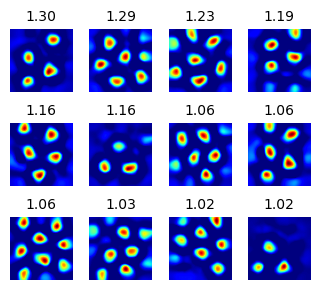

In [16]:
plot_gcs(gc_pcn, scores_pcn, 'pcn_gcs')

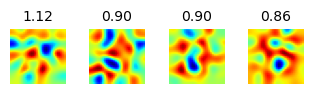

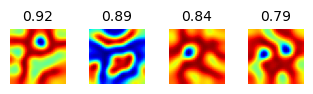

In [26]:
nosparse_path = 'results/pcn/sparse_False_relu_True'
norelu_path = 'results/pcn/sparse_True_relu_False'
gc_and_scores_nosparse = np.load(os.path.join(nosparse_path, 'gc_and_scores.npz'))
gcs_nosparse = gc_and_scores_nosparse['gcs']
scores_nosparse = gc_and_scores_nosparse['scores']

gc_and_scores_norelu = np.load(os.path.join(norelu_path, 'gc_and_scores.npz'))
gcs_norelu = gc_and_scores_norelu['gcs']
scores_norelu = gc_and_scores_norelu['scores']

plot_gcs(gcs_nosparse, scores_nosparse, 'nosparse_gcs', nrow=1, ncol=4)
plot_gcs(gcs_norelu, scores_norelu, 'norelu_gcs', nrow=1, ncol=4)

## Comparison between RNN and tPC

In [13]:
path_rnns = ["Jun-07-2024-22-03-53", "Jun-07-2024-22-20-31", "Jun-07-2024-22-36-13"]
path_pcns = ["May-08-2024-14-20-04", "Jun-08-2024-09-53-42", "Jun-08-2024-09-53-44"]
path_tbptt = ["Jun-11-2024-21-54-06", "Jun-15-2024-14-25-41", "Jun-15-2024-14-39-10"]

C:\Users\mufen\AppData\Local\Temp\ipykernel_8388\2863790094.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt_tpc = torch.load(os.path.join(tpc_path, 'models', 'most_

Initializing new model from scratch.
Initializing new model from scratch.


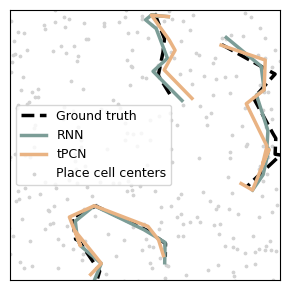

In [14]:
pos, pred_rnn, pred_tpc = get_trajetories(path_pcns[2], path_rnns[2])
plt.figure(figsize=(3, 3))
for i in range(3):
    plt.plot(pos[i, :, 0], pos[i, :, 1], 'k', linewidth=2.5, ls='--', label='Ground truth' if i == 0 else None)
    plt.plot(pred_rnn[i, :, 0], pred_rnn[i, :, 1], "#7c9d97", linewidth=2.5, label='RNN' if i == 0 else None)
    plt.plot(pred_tpc[i, :, 0], pred_tpc[i, :, 1], "#e9b383", linewidth=2.5, label='tPCN' if i == 0 else None)
    plt.xticks([])
    plt.yticks([])
    plt.xlim(-0.35, 0.7)
    plt.ylim(-0.35, 0.7)
plt.scatter(centers[:,0], centers[:,1], c='lightgrey', label='Place cell centers', s=3)
plt.legend(fontsize=9, loc='center left')
plt.tight_layout()
# plt.savefig('figures/trajectories_tpc_rnn.pdf', bbox_inches='tight')
plt.show()

In [15]:
def plot_gcs(rate_map, scores, save_name=None, nrow=3, ncol=4):
    fig, ax = plt.subplots(nrow, ncol, figsize=(ncol, nrow))
    for i, ax in enumerate(ax.flatten()):
        r = (rate_map[i] - rate_map[i].min()) / (rate_map[i].max() - rate_map[i].min())
        ax.imshow(r, cmap='jet')
        ax.axis('off')
        ax.set_title(f'{scores[i]:.2f}', fontsize=10)
    plt.tight_layout()
    fig.subplots_adjust(hspace=0.5, right=0.8)
    # plt.savefig(f'figures/{save_name}.pdf', bbox_inches='tight')
    plt.show()

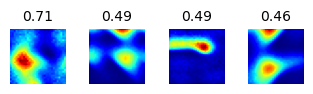

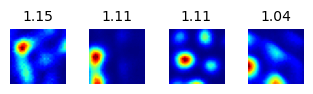

In [17]:
gcs_rnn = np.load(os.path.join('../results/rnn', path_rnns[2], 'top64_grid_cells.npy'))
gcs_tpc = np.load(os.path.join('../results/tpc', path_pcns[2], 'top64_grid_cells.npy'))
# gcs_tbptt = np.load(os.path.join('../results/rnn', path_tbptt[0], 'top64_grid_cells.npy'))

scores_rnn = np.load(os.path.join('../results/rnn', path_rnns[2], 'grid_scores.npy'))
scores_tpc = np.load(os.path.join('../results/tpc', path_pcns[2], 'grid_scores.npy'))
# scores_tbptt = np.load(os.path.join('../results/rnn', path_tbptt[0], 'grid_scores.npy'))

plot_gcs(gcs_rnn, scores_rnn, 'rnn_gcs_fast', nrow=1, ncol=4)
plot_gcs(gcs_tpc, scores_tpc, 'tpc_gcs_fast', nrow=1, ncol=4)

In [ ]:
gcs_rnn = np.load(os.path.join('../results/rnn', path_rnns[0], 'top64_grid_cells.npy'))
gcs_tpc = np.load(os.path.join('../results/tpc', path_pcns[0], 'top64_grid_cells.npy'))
# gcs_tbptt = np.load(os.path.join('./results/rnn', path_tbptt[0], 'top64_grid_cells.npy'))

scores_rnn = np.load(os.path.join('../results/rnn', path_rnns[0], 'grid_scores.npy'))
scores_tpc = np.load(os.path.join('../results/tpc', path_pcns[0], 'grid_scores.npy'))
# scores_tbptt = np.load(os.path.join('./results/rnn', path_tbptt[0], 'grid_scores.npy'))

plot_gcs(gcs_rnn, scores_rnn, 'rnn_gcs_slow', nrow=1, ncol=8)
plot_gcs(gcs_tpc, scores_tpc, 'tpc_gcs_slow', nrow=1, ncol=8)
# plot_gcs(gcs_tbptt, scores_tbptt)

In [ ]:
rnns = []
tpcs = []
tbptts = []
baselines = []
for i in range(3):
    errs_rnn = get_PI_performance(
        os.path.join('rnn', path_rnns[i]),
        model='rnn',
        verbose=(i == 2)
    )
    errs_tpc = get_PI_performance(
        os.path.join('tpc', path_pcns[i]),
        model='tpc',
        verbose=(i == 2)
    )
    # errs_tbptt = get_PI_performance(
    #     os.path.join('rnn', path_tbptt[i]),
    #     model='rnn',
    #     verbose=(i == 2)
    # )
    rnns.append(errs_rnn[0])
    tpcs.append(errs_tpc[0])
    # tbptts.append(errs_tbptt[0])
    baselines.append([errs_rnn[1], errs_tpc[1], errs_tbptt[1]])

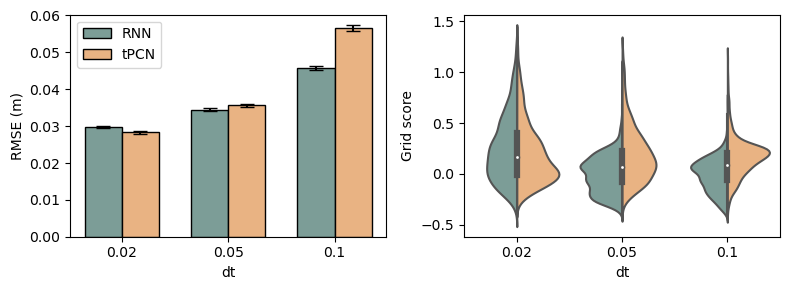

In [10]:
rnns = np.array(rnns)
tpcs = np.array(tpcs)
tbptts = np.array(tbptts)
baselines = np.array(baselines).reshape((3, -1)).mean(1)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# Bar Plot
bar_width = 0.35
index = np.arange(len(rnns))

axes[0].bar(
    index - bar_width/2,
    rnns.mean(axis=1),
    bar_width,
    yerr=rnns.std(axis=1),
    label='RNN',
    color='#7c9d97',
    capsize=5,
    edgecolor='black',
    align='center',
)
axes[0].bar(
    index + bar_width/2,
    tpcs.mean(axis=1),
    bar_width,
    yerr=tpcs.std(axis=1),
    label='tPCN',
    color='#e9b383',
    capsize=5,
    edgecolor='black',
    align='center',
)

axes[0].set_xlabel('dt')
axes[0].set_ylabel('RMSE (m)')
axes[0].set_xticks(index)
axes[0].set_xticklabels(['0.02', '0.05', '0.1'])
axes[0].legend()

# Violin Plot
rnn_score = []
tpc_score = []
for i in range(3):
    rnn_score.append(np.load(os.path.join('./results/', 'rnn', path_rnns[i], 'grid_scores.npy')))
    tpc_score.append(np.load(os.path.join('./results/', 'tpc', path_pcns[i], 'grid_scores.npy')))
rnn_score = np.array(rnn_score)
tpc_score = np.array(tpc_score)

data = []
for i in range(3):
    for score in rnn_score[i]:
        data.append([i, 'RNN', score])
    for score in tpc_score[i]:
        data.append([i, 'TPC', score])

df = pd.DataFrame(data, columns=['Group', 'Type', 'Score'])
palette = {"RNN": "#7c9d97", "TPC": "#e9b383"}

sns.violinplot(
    x='Group',
    y='Score',
    hue='Type',
    data=df,
    split=True,
    inner="box",
    palette=palette,
    saturation=1.5,
    ax=axes[1],
    linecolor='black',
    legend=False
)

axes[1].set_xlabel('dt')
axes[1].set_ylabel('Grid score')
axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels(['0.02', '0.05', '0.1'])
axes[1].legend([], frameon=False)

# Save the entire figure
plt.tight_layout()
plt.savefig('figures/combined_performance_grid_scores_rnn_tpc.pdf', bbox_inches='tight')
plt.show()

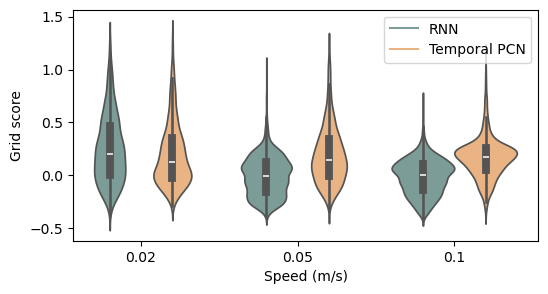

In [57]:
rnn_score = []
tpc_score = []
for i in range(3):
    rnn_score.append(np.load(os.path.join('../results/', 'rnn', path_rnns[i], 'grid_scores.npy')))
    tpc_score.append(np.load(os.path.join('../results/', 'tpc', path_pcns[i], 'grid_scores.npy')))
rnn_score = np.array(rnn_score)
tpc_score = np.array(tpc_score)

data = []
for i in range(3):
    for score in rnn_score[i]:
        data.append([i, 'RNN', score])
    for score in tpc_score[i]:
        data.append([i, 'Temporal PCN', score])

df = pd.DataFrame(data, columns=['Group', 'Type', 'Score'])
palette = {"RNN": "#7c9d97", "Temporal PCN": "#e9b383"}
# Plot
plt.figure(figsize=(6, 3))
v = sns.violinplot(
    x='Group', 
    y='Score', 
    hue='Type', 
    data=df, 
    # split=True, 
    inner="box", 
    palette=palette,
    saturation=1.,
    legend=False,
    # linecolor='gray',
)
# v.get_legend().remove()
# plt.title('Paired Violin Plots')
# plot legend with palette colors
for i, key in enumerate(palette):
    plt.plot([], [], color=palette[key], label=key)
plt.legend(loc='upper right')
plt.xlabel('Speed (m/s)')
plt.ylabel('Grid score')
plt.xticks([0,1,2], ['0.02', '0.05', '0.1'])
plt.savefig('../results/figures/grid_scores_rnn_tpc', bbox_inches='tight', dpi=200)
plt.show()

## Comparison between with and without velocity inputs

In [7]:
path_v = os.path.join("tpc", "Jun-08-2024-09-51-30")
path_no_v = os.path.join("tpc", "Jun-09-2024-09-54-38")

In [8]:
errs_v, _ = get_PI_performance(path_v, repeats=5)

Initializing new model from scratch.
Get performance...


100%|██████████| 5/5 [00:01<00:00,  2.52it/s]


In [9]:
errs_no_v, baseline_errs = get_PI_performance(path_no_v, repeats=5)

Initializing new model from scratch.
Get performance...


100%|██████████| 5/5 [00:01<00:00,  3.21it/s]


In [10]:
scores_v = np.load(os.path.join('./results', path_v, 'grid_scores.npy'))
scores_no_v = np.load(os.path.join('./results', path_no_v, 'grid_scores.npy'))

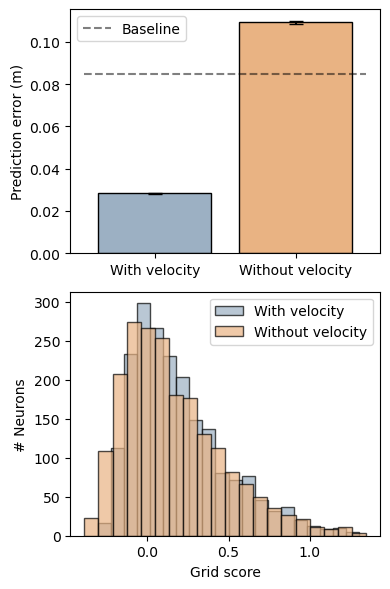

In [11]:
fig, axs = plt.subplots(2, 1, figsize=(4, 6))

# Plot 1: Prediction error
axs[0].bar(
    ['With velocity', 'Without velocity'], 
    [np.mean(errs_v), np.mean(errs_no_v)], 
    yerr=[np.std(errs_v), np.std(errs_no_v)], 
    capsize=5,
    color=['#9cb0c3', '#e9b383'],
    edgecolor='black'
)
axs[0].hlines(
    np.mean(baseline_errs), 
    -0.5, 
    1.5, 
    color='k', 
    linestyles='dashed', 
    label='Baseline',
    alpha=0.5
)
axs[0].set_ylabel('Prediction error (m)')
axs[0].legend()

# Plot 2: Grid score histogram
axs[1].hist(scores_v, bins=20, alpha=0.7, label='With velocity', color='#9cb0c3', edgecolor='black')
axs[1].hist(scores_no_v, bins=20, alpha=0.7, label='Without velocity', color='#e9b383', edgecolor='black')
axs[1].legend()
axs[1].set_xlabel('Grid score')
axs[1].set_ylabel('# Neurons')

plt.tight_layout()
plt.show()


In [12]:
gcs_v = np.load(os.path.join('./results', path_v, 'top64_grid_cells.npy'))
gcs_no_v = np.load(os.path.join('./results', path_no_v, 'top64_grid_cells.npy'))

In [13]:
def plot_gcs(rate_map, scores):
    fig, ax = plt.subplots(4, 5, figsize=(5, 4))
    for i, ax in enumerate(ax.flatten()):
        r = (rate_map[i] - rate_map[i].min()) / (rate_map[i].max() - rate_map[i].min())
        ax.imshow(r, cmap='jet')
        ax.axis('off')
        ax.set_title(f'{scores[i]:.2f}', fontsize=10)
    plt.tight_layout()
    fig.subplots_adjust(hspace=0.5, right=0.8)
    plt.show()

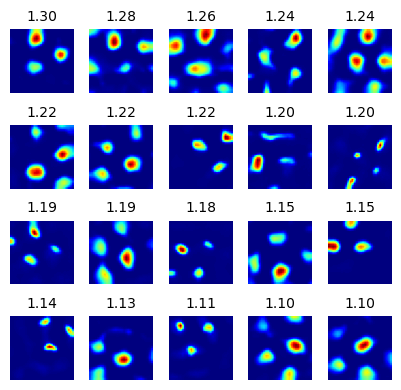

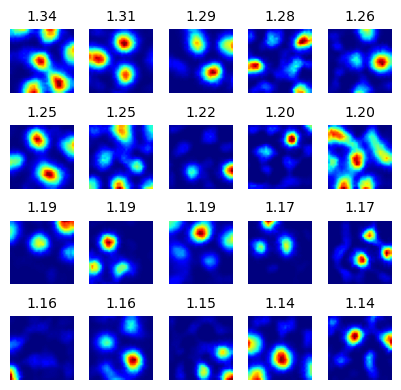

In [14]:
plot_gcs(gcs_v, scores_v)
plot_gcs(gcs_no_v, scores_no_v)

In [54]:
def get_trajectories_v(tpc1_path, tpc2_path):
    options_tpc1 = Options()
    options_tpc2 = Options()

    tpc1_path = os.path.join('./results', tpc1_path)
    options_tpc1.load_from_json(os.path.join(tpc1_path, 'configs.json'))
    ckpt_tpc1 = torch.load(os.path.join(tpc1_path, 'models', 'most_recent_model.pth'))
    options_tpc1.save_dir = tpc1_path

    tpc2_path = os.path.join('./results', tpc2_path)
    options_tpc2.load_from_json(os.path.join(tpc2_path, 'configs.json'))
    ckpt_tpc2 = torch.load(os.path.join(tpc2_path, 'models', 'most_recent_model.pth'))
    options_tpc2.save_dir = tpc2_path

    place_cell = PlaceCells(options_tpc1)
    generator = TrajectoryGenerator(options_tpc1, place_cell)

    tpc1 = TemporalPCN(options_tpc1).to(options_tpc1.device)
    init_model1 = HierarchicalPCN(options_tpc1).to(options_tpc1.device)
    tpc1.load_state_dict(ckpt_tpc1['model'])
    init_model1.load_state_dict(ckpt_tpc1['init_model'])
    pc_trainer1 = PCTrainer(options_tpc1, tpc1, init_model1, generator, place_cell, restore=False)

    tpc2 = TemporalPCN(options_tpc2).to(options_tpc2.device)
    init_model2 = HierarchicalPCN(options_tpc2).to(options_tpc2.device)
    tpc2.load_state_dict(ckpt_tpc2['model'])
    init_model2.load_state_dict(ckpt_tpc2['init_model'])
    pc_trainer2 = PCTrainer(options_tpc2, tpc2, init_model2, generator, place_cell, restore=False)

    # Generate trajectories (one batch)
    inputs, _, pos_batch = generator.get_test_batch()
    
    pred_tpc1, _ = pc_trainer1.predict(inputs)
    pred_tpc1 = place_cell.get_nearest_cell_pos(F.softmax(pred_tpc1.detach(), dim=-1)).detach().cpu().numpy()
    
    pred_tpc2, _ = pc_trainer2.predict(inputs)
    pred_tpc2 = place_cell.get_nearest_cell_pos(F.softmax(pred_tpc2.detach(), dim=-1)).detach().cpu().numpy()

    return pos_batch.detach().cpu().numpy(), pred_tpc1, pred_tpc2

Initializing new model from scratch.
Initializing new model from scratch.


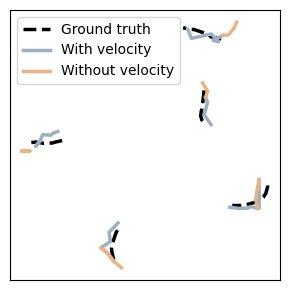

In [59]:
pos, pred_v, pred_no_v = get_trajectories_v(path_v, path_no_v)
plt.figure(figsize=(3, 3))
for i in range(5):
    plt.plot(pos[i, :, 0], pos[i, :, 1], 'k', linewidth=2.5, ls='--', label='Ground truth' if i == 0 else None)
    plt.plot(pred_v[i, :, 0], pred_v[i, :, 1], "#9cb0c3", linewidth=2.5, label='With velocity' if i == 0 else None)
    plt.plot(pred_no_v[i, :, 0], pred_no_v[i, :, 1], "#e9b383", linewidth=2.5, label='Without velocity' if i == 0 else None)
    plt.xticks([])
    plt.yticks([])
plt.legend()
plt.tight_layout()
plt.show()

## Robustness against multiple things
- nonlinearity
    - tanh (out): Jun-08-2024-09-42-09
    - tanh (rec): Jun-23-2024-15-55-56 
- env size
    - 1.8: Jun-11-2024-12-24-56
    - 1.2: Jun-23-2024-16-04-25
- model size
    - 256: Jun-11-2024-12-30-49
    - 512: Jun-16-2024-20-21-47
    - 1024: Jun-16-2024-20-21-54
- Gaussian PCs 
    - Gaussian: Jun-23-2024-15-55-14
- no velocity input:
    - Jun-09-2024-09-54-38

Overall, show in one violin plot of the grid scores and show in multiple panels the grid cell examples.

cmaps:
- Green_Orange_Teal
- Hiroshige
- Miller_Stone

In [35]:
base_path = os.path.join("tpc", "Jun-08-2024-09-51-30")
tanh_out_path = os.path.join("tpc", "Jun-08-2024-09-42-09")
tanh_rec_path = os.path.join("tpc", "Jun-23-2024-15-55-56")
big_env_path = os.path.join("tpc", "Jun-11-2024-12-24-56")
small_env_path = os.path.join("tpc", "Jun-23-2024-16-04-25")
gaussian_path = os.path.join("tpc", "Jun-23-2024-15-55-14")
small256_model_path = os.path.join("tpc", "Jun-11-2024-12-30-49")
small512_model_path = os.path.join("tpc", "Jun-16-2024-20-21-47")
small1024_model_path = os.path.join("tpc", "Jun-16-2024-20-21-54")
no_v_path = os.path.join("tpc", "Jun-09-2024-09-54-38")

errs_base, bl_base = get_PI_performance(base_path, repeats=5)
errs_tanh_out, bl_tanh_out = get_PI_performance(tanh_out_path, repeats=5)
errs_tanh_rec, bl_tanh_rec = get_PI_performance(tanh_rec_path, repeats=5)
errs_big_env, bl_big_env = get_PI_performance(big_env_path, repeats=5)
errs_small_env, bl_small_env = get_PI_performance(small_env_path, repeats=5)
errs_gaussian, bl_gaussian = get_PI_performance(gaussian_path, repeats=5)
errs_small256, bl_small256 = get_PI_performance(small256_model_path, repeats=5)
errs_small512, bl_small512 = get_PI_performance(small512_model_path, repeats=5)
errs_small1024, bl_small1024 = get_PI_performance(small1024_model_path, repeats=5)
errs_no_v, bl_no_v = get_PI_performance(no_v_path, repeats=5)

Initializing new model from scratch.
Get performance...


100%|██████████| 5/5 [00:01<00:00,  3.23it/s]


Initializing new model from scratch.
Get performance...


100%|██████████| 5/5 [00:00<00:00, 27.62it/s]


Initializing new model from scratch.
Get performance...


...

100%|██████████| 5/5 [00:01<00:00,  3.39it/s]


Initializing new model from scratch.
Get performance...


100%|██████████| 5/5 [00:01<00:00,  3.34it/s]


Initializing new model from scratch.
Get performance...


100%|██████████| 5/5 [00:01<00:00,  3.17it/s]


In [36]:
scores_base = np.load(os.path.join('./results', base_path, 'grid_scores.npy'))
scores_tanh_out = np.load(os.path.join('./results', tanh_out_path, 'grid_scores.npy'))
scores_tanh_rec = np.load(os.path.join('./results', tanh_rec_path, 'grid_scores.npy'))
scores_big_env = np.load(os.path.join('./results', big_env_path, 'grid_scores.npy'))
scores_small_env = np.load(os.path.join('./results', small_env_path, 'grid_scores.npy'))
scores_gaussian = np.load(os.path.join('./results', gaussian_path, 'grid_scores.npy'))
scores_small256 = np.load(os.path.join('./results', small256_model_path, 'grid_scores.npy'))
scores_small512 = np.load(os.path.join('./results', small512_model_path, 'grid_scores.npy'))
scores_small1024 = np.load(os.path.join('./results', small1024_model_path, 'grid_scores.npy'))
scores_no_v = np.load(os.path.join('./results', no_v_path, 'grid_scores.npy'))

In [37]:
#7992A6FF, #C0D1CEFF, #BCB584FF, #70684DFF, #383733FF

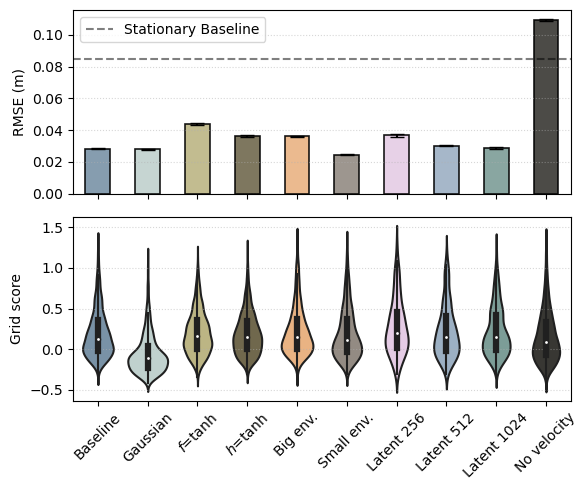

In [38]:
# colors = ['#693829FF', '#894B33FF', '#A56A3EFF', '#CFB267FF', '#D9C5B6FF', '#9CA9BAFF', '#5480B5FF', '#3D619DFF', '#405A95FF', '#345084FF]

# Prepare the categories and data for the plots
categories = ['Baseline', 'Gaussian', r'$f$=tanh', r'$h$=tanh', 'Big env.', 'Small env.', 
              'Latent 256', 'Latent 512', 'Latent 1024', 'No velocity']
scores = [scores_base, scores_gaussian, scores_tanh_out, scores_tanh_rec, scores_big_env, 
          scores_small_env, scores_small256, scores_small512, 
          scores_small1024, scores_no_v]

# First plot data (violin)
data = []
for category, score_array in zip(categories, scores):
    for score in score_array:
        data.append((category, score))
df_long = pd.DataFrame(data, columns=['Category', 'Grid score'])

# Second plot data (bar)
errors = [errs_base, errs_gaussian, errs_tanh_out, errs_tanh_rec, errs_big_env, errs_small_env, 
          errs_small256, errs_small512, errs_small1024, errs_no_v]
bls = [bl_base, bl_gaussian, bl_tanh_out, bl_tanh_rec, bl_big_env, bl_small_env,
       bl_small256, bl_small512, bl_small1024, bl_no_v]
means = [np.mean(err) for err in errors]
bl_means = [np.mean(bl) for bl in bls]
std_devs = [np.std(err) for err in errors]

# Color map
# cmap = load_cmap("Green_Orange_Teal")(np.linspace(0.1, 1, len(df_long['Category'].unique())))
cmap = mpl.colors.ListedColormap(
    ['#7992A6FF', '#C0D1CEFF', '#BCB584FF', '#70684DFF', '#E9B383FF', '#938B83', '#E5CCE5FF', '#9CB0C3FF', '#7C9D97FF', '#383733FF']
)
# Set up the subplots
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(6, 5), sharex=True)
plt.subplots_adjust(hspace=0.3)



# Second subplot (bar plot)
x = np.arange(len(categories))
axes[0].bar(x, means, yerr=std_devs, capsize=5, alpha=0.9, color=cmap.colors, width=0.5, edgecolor='black', linewidth=1.2)
axes[0].set_ylabel('RMSE (m)')
# axes[0].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
axes[0].grid(axis='y', ls=':', alpha=0.5)
# axes[0].set_title('Mean Prediction Errors with Standard Deviation')

axes[0].hlines(
    np.mean(bl_means), 
    -0.5, 
    9.5, 
    color='k', 
    linestyles='dashed', 
    label='Stationary Baseline',
    alpha=0.5
)
axes[0].legend()

# First subplot (violin plot)
sns.violinplot(
    x='Category', 
    y='Grid score', 
    data=df_long, 
    palette=cmap.colors, 
    # color="#e9b383",
    saturation=1,
    alpha=0.7,
    ax=axes[1]
)
# axes[1].set_title('Distribution of Grid Scores by Category')
axes[1].set_xlabel('')
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories, rotation=45)
axes[1].grid(axis='y', ls=':', alpha=0.5)
# axes[1].ticklabel_format(axis='y', style='sci', scilimits=(0,0))

# Display the plot
plt.tight_layout()
plt.savefig('figures/robustness.pdf', bbox_inches='tight')
plt.show()

In [51]:
def plot_gcs(rate_map, scores, save_name=None, nrow=3, ncol=4):
    fig, ax = plt.subplots(nrow, ncol, figsize=(ncol, nrow))
    for i, ax in enumerate(ax.flatten()):
        r = (rate_map[i] - rate_map[i].min()) / (rate_map[i].max() - rate_map[i].min())
        ax.imshow(r, cmap='jet')
        ax.axis('off')
        ax.set_title(f'{scores[i]:.2f}', fontsize=10)
    plt.tight_layout()
    fig.subplots_adjust(hspace=0.5, right=0.8)
    plt.savefig(f'figures/{save_name}.pdf', bbox_inches='tight')
    plt.show()

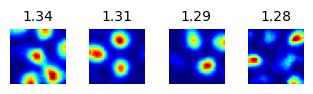

In [52]:
plot_gcs(gcs_no_v, scores_no_v, 'no_v_gcs', nrow=1, ncol=4)

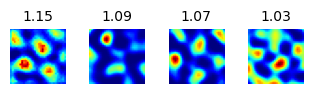

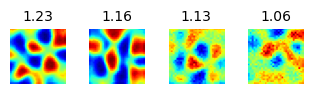

In [38]:
plot_gcs(gcs_tanh_out, scores_tanh_out, 'tanh_out_gcs', nrow=1, ncol=4)
plot_gcs(gcs_tanh_rec, scores_tanh_rec, 'tanh_rec_gcs', nrow=1, ncol=4)

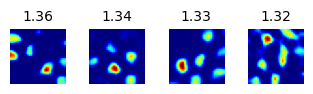

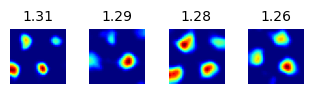

In [40]:
plot_gcs(gcs_big_env, scores_big_env, 'big_env_gcs', nrow=1, ncol=4)
plot_gcs(gcs_small_env, scores_small_env, 'small_env_gcs', nrow=1, ncol=4)

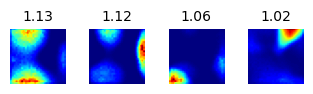

In [39]:
plot_gcs(gcs_gaussian, scores_gaussian, 'gaussian_gcs', nrow=1, ncol=4)

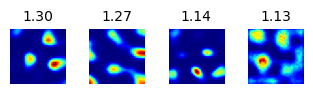

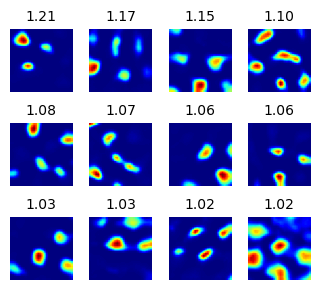

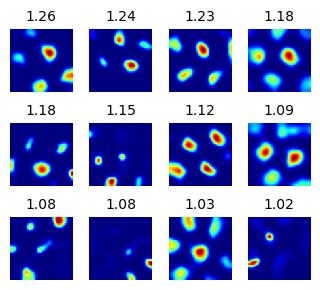

In [41]:
plot_gcs(gcs_small256_model, scores_small256_model, 'small256_model_gcs', nrow=1, ncol=4)
plot_gcs(gcs_small512_model, scores_small512_model, 'small512_model_gcs')
plot_gcs(gcs_small1024_model, scores_small1024_model, 'small1024_model_gcs')

## Comparison between tPC and TBPTT

1 infer iters: Jun-25-2024-14-07-36

5 infer iters: Jun-24-2024-17-10-53

10 infer iters: Jun-25-2024-07-21-52

50 infer iters: Jun-25-2024-07-20-24

In [31]:
path_tpc1 = os.path.join("tpc", "Jun-25-2024-14-07-36")
path_tpc5 = os.path.join("tpc", "Jun-24-2024-17-10-53")
path_tpc10 = os.path.join("tpc", "Jun-25-2024-07-21-52")
path_tpc20 = os.path.join("tpc", "Jun-08-2024-09-51-30")
path_tpc50 = os.path.join("tpc", "Jun-25-2024-07-20-24")
path_bptt = os.path.join("rnn", "Jun-07-2024-22-03-53")
path_tbptt = os.path.join("rnn", "Jun-11-2024-21-54-06")
paths = [path_tbptt, path_tpc1, path_tpc5, path_tpc10, path_tpc20, path_tpc50, path_bptt]

In [32]:
categories = ['tBPTT', 'tPCN1', 'tPCN5', 'tPCN10', 'tPCN20', 'tPCN50', 'BPTT']
errors = [get_PI_performance(path, model=('tpc' if "tpc" in path else 'rnn'), repeats=5)[0] for path in paths]

# Calculate mean and standard deviation for each set of errors
means = [np.mean(err) for err in errors]
std_devs = [np.std(err) for err in errors]

Initializing new model from scratch.
Get performance...


100%|██████████| 5/5 [00:00<00:00, 11.43it/s]


Initializing new model from scratch.
Get performance...


100%|██████████| 5/5 [00:01<00:00,  3.12it/s]


Initializing new model from scratch.
Get performance...


...

100%|██████████| 5/5 [00:01<00:00,  3.11it/s]


Initializing new model from scratch.
Get performance...


100%|██████████| 5/5 [00:01<00:00,  3.12it/s]


Initializing new model from scratch.
Get performance...


100%|██████████| 5/5 [00:00<00:00, 41.34it/s]


In [33]:
scores = [np.load(os.path.join('./results', path, 'grid_scores.npy')) for path in paths]

# Prepare the categories and data for the plots
categories = ['tBPTT', 'tPCN1', 'tPCN5', 'tPCN10', 'tPCN20', 'tPCN50', 'BPTT']
data = []
for category, score_array in zip(categories, scores):
    for score in score_array:
        data.append((category, score))
df_long = pd.DataFrame(data, columns=['Category', 'Grid score'])

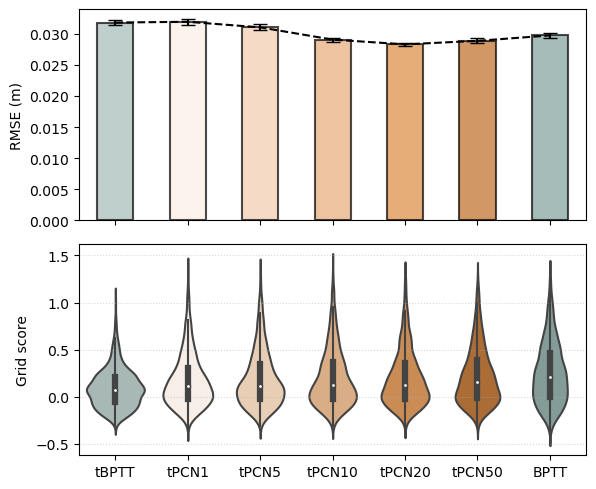

In [34]:
x = np.arange(len(categories))  # the label locations
# Apply color by category logic
colors = ['#a4bbb7', '#faeee4', '#f1cdae', '#e7ac78', '#dd8b41', '#be6b22', '#7fa09a']
# Set up the plot
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(6, 5), sharex=True)

# First subplot (bar plot)
axes[0].bar(x, means, yerr=std_devs, capsize=5, alpha=0.7, color=colors, width=0.5, edgecolor='black', linewidth=1.5)
axes[0].plot(x, means, color='black', alpha=1, ls='--', lw=1.5)
axes[0].set_ylabel('RMSE (m)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories)

# Second subplot (violin plot)
axes[1].grid(axis='y', ls=':', alpha=0.5)
sns.violinplot(x='Category', y='Grid score', data=df_long, palette=colors, ax=axes[1])
axes[1].set_xlabel('')

# Adjust spacing between subplots
plt.subplots_adjust(hspace=0.3)

# Display the plot
plt.tight_layout()
plt.savefig('figures/tbptt.pdf', bbox_inches='tight')
plt.show()

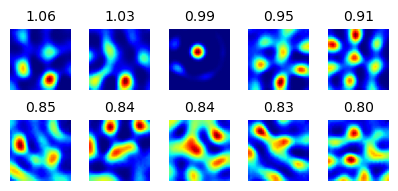

In [56]:
gcs_tbptt = np.load(os.path.join('./results', path_tbptt, 'top64_grid_cells.npy'))
scores_tbptt = np.load(os.path.join('./results', path_tbptt, 'grid_scores.npy'))
def plot_gcs(rate_map, scores, save_name=None, nrow=3, ncol=4):
    fig, ax = plt.subplots(nrow, ncol, figsize=(ncol, nrow))
    for i, ax in enumerate(ax.flatten()):
        r = (rate_map[i] - rate_map[i].min()) / (rate_map[i].max() - rate_map[i].min())
        ax.imshow(r, cmap='jet')
        ax.axis('off')
        ax.set_title(f'{scores[i]:.2f}', fontsize=10)
    plt.tight_layout()
    fig.subplots_adjust(hspace=0.5, right=0.8)
    plt.savefig(f'figures/{save_name}.pdf', bbox_inches='tight')
    plt.show()
plot_gcs(gcs_tbptt, scores_tbptt, 'tbptt_gcs', nrow=2, ncol=5)